
# Deep Convolutional Neural Networks Lab
##### By Prof. Dr. Heinke Hihn, IU Berlin, CSE Deep Learning Course

## Learning Objectives
By the end of this lab, you will be able to:
1. Build a deep CNN architecture from scratch using PyTorch
2. Understand and implement key components: Conv layers, Pooling, Batch Normalization, Dropout
3. Train a CNN on a real image dataset
4. Evaluate model performance and visualize results
5. Experiment with architectural choices and hyperparameters

## Prerequisites
- Basic understanding of neural networks and backpropagation
- Familiarity with feedforward networks
- Basic knowledge of convolution operations
- Python and PyTorch basics


## Part 1: Setup and Data Preparation

Let's start by importing the necessary libraries and loading our dataset.
We'll use CIFAR-10, a dataset of 60,000 32x32 color images in 10 classes.


In [1]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


### 1.1 Data Augmentation and Preprocessing

Data augmentation is crucial for training robust CNNs. It artificially expands the training set by applying random transformations.

**Common augmentations for image data:**
- Random horizontal flipping
- Random cropping
- Color jittering
- Random rotation

**Normalization:** We normalize images using the mean and standard deviation of the dataset. This helps with training stability.

In [2]:
# %%
# CIFAR-10 statistics (pre-computed)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

# Define transforms for training data (with augmentation)
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

# Define transforms for test data (no augmentation, only normalization)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

# Load CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

100%|██████████| 170M/170M [00:05<00:00, 30.1MB/s]


Now let's have a look at the data:

In [3]:
# Class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(class_names)}")
print(f"Image shape: {train_dataset[0][0].shape}")

Training samples: 50000
Test samples: 10000
Number of classes: 10
Image shape: torch.Size([3, 32, 32])


Let's create the data loaders:

In [4]:
# Create data loaders
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# TODO: create the test data loader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


<details>
<summary>Click here for solution</summary>

```python
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Visualize some training samples


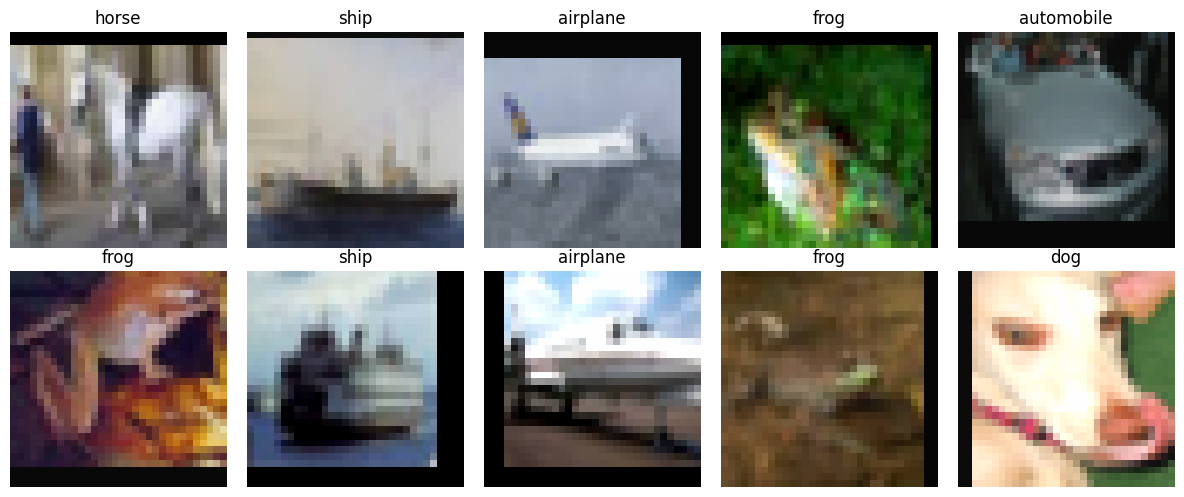

In [5]:
def show_images(dataset, n_images=10):
    """Display random images from the dataset."""
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.flatten()

    # Get random indices
    indices = np.random.choice(len(dataset), n_images, replace=False)

    for ax, idx in zip(axes, indices):
        # Get image and label
        img, label = dataset[idx]

        # Denormalize for visualization
        img = img.numpy().transpose(1, 2, 0)
        img = img * np.array(CIFAR10_STD) + np.array(CIFAR10_MEAN)
        img = np.clip(img, 0, 1)

        ax.imshow(img)
        ax.set_title(class_names[label])
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_images(train_dataset)

## Part 2: Building CNN Components

Before we build a complete CNN, let's understand the individual components.

### 2.1 Convolutional Layer Recap

A convolutional layer applies learned filters to the input. Key parameters:
- **in_channels**: Number of input channels (e.g., 3 for RGB)
- **out_channels**: Number of filters (determines output channels)
- **kernel_size**: Size of the filter (e.g., 3x3)
- **stride**: Step size when sliding the filter
- **padding**: Zero-padding added to input borders

**Output size formula:**
$$H_{out} = \frac{H_{in} + 2 \times padding - kernel\_size}{stride} + 1$$

In [6]:
# Let's visualize how convolution changes feature map dimensions
def print_conv_output_shape(in_channels, out_channels, kernel_size, stride, padding, input_size):
    """Calculate and print the output shape after a conv layer."""
    conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
    dummy_input = torch.randn(1, in_channels, input_size, input_size)
    output = conv(dummy_input)
    print(f"Input:  {list(dummy_input.shape)}")
    print(f"Conv2d(in={in_channels}, out={out_channels}, k={kernel_size}, s={stride}, p={padding})")
    print(f"Output: {list(output.shape)}")
    print()

print("Example 1: 3x3 conv with padding=1 (preserves spatial size)")
print_conv_output_shape(3, 64, kernel_size=3, stride=1, padding=1, input_size=32)

print("Example 2: 3x3 conv with stride=2 (downsamples by 2)")
print_conv_output_shape(64, 128, kernel_size=3, stride=2, padding=1, input_size=32)

print("Example 3: 5x5 conv without padding")
print_conv_output_shape(3, 64, kernel_size=5, stride=1, padding=0, input_size=32)

Example 1: 3x3 conv with padding=1 (preserves spatial size)
Input:  [1, 3, 32, 32]
Conv2d(in=3, out=64, k=3, s=1, p=1)
Output: [1, 64, 32, 32]

Example 2: 3x3 conv with stride=2 (downsamples by 2)
Input:  [1, 64, 32, 32]
Conv2d(in=64, out=128, k=3, s=2, p=1)
Output: [1, 128, 16, 16]

Example 3: 5x5 conv without padding
Input:  [1, 3, 32, 32]
Conv2d(in=3, out=64, k=5, s=1, p=0)
Output: [1, 64, 28, 28]



### 2.2 Batch Normalization

Batch Normalization normalizes the activations of each layer, which:
- Accelerates training
- Allows higher learning rates
- Provides some regularization
- Reduces sensitivity to initialization

For each feature channel, it normalizes:
$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

Then applies learnable parameters γ and β:
$$y = \gamma \hat{x} + \beta$$

In [7]:
# Batch Normalization demonstration
def demonstrate_batch_norm():
    """Show how batch normalization affects activations."""
    # Create sample activations with varying distributions
    x = torch.randn(100, 64, 8, 8) * 5 + 10  # High variance, shifted mean

    bn = nn.BatchNorm2d(64)
    bn.eval()  # Use running statistics

    # First, let's update running statistics with some forward passes in training mode
    bn.train()
    for _ in range(100):
        _ = bn(torch.randn(100, 64, 8, 8) * 5 + 10)
    bn.eval()

    x_normalized = bn(x)

    print(f"Before BatchNorm - Mean: {x.mean():.4f}, Std: {x.std():.4f}")
    print(f"After BatchNorm  - Mean: {x_normalized.mean():.4f}, Std: {x_normalized.std():.4f}")

demonstrate_batch_norm()

Before BatchNorm - Mean: 9.9917, Std: 4.9971
After BatchNorm  - Mean: -0.0015, Std: 0.9994


### 2.3 Pooling Layers

Pooling reduces spatial dimensions and provides translation invariance.

**Types of pooling:**
- **Max Pooling**: Takes the maximum value in each window
- **Average Pooling**: Takes the average value in each window
- **Global Average Pooling**: Reduces each feature map to a single value

In [8]:
# Pooling demonstration
x = torch.randn(1, 64, 32, 32)

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
global_avg_pool = nn.AdaptiveAvgPool2d(1)

print(f"Input shape:              {list(x.shape)}")
print(f"After MaxPool2d(2,2):     {list(max_pool(x).shape)}")
print(f"After AvgPool2d(2,2):     {list(avg_pool(x).shape)}")
print(f"After Global Avg Pool:    {list(global_avg_pool(x).shape)}")

Input shape:              [1, 64, 32, 32]
After MaxPool2d(2,2):     [1, 64, 16, 16]
After AvgPool2d(2,2):     [1, 64, 16, 16]
After Global Avg Pool:    [1, 64, 1, 1]


## Part 3: Building a CNN Architecture

Now let's build a complete CNN! We'll start with a simple architecture and then move to a more sophisticated one.

### 3.1 Simple CNN (Warm-up)

**EXERCISE 1:** Complete the SimpleCNN class below.

**Architecture:**
- Conv Block 1: Conv(3→32, 3x3) → BatchNorm → ReLU → MaxPool(2x2)
- Conv Block 2: Conv(32→64, 3x3) → BatchNorm → ReLU → MaxPool(2x2)
- Conv Block 3: Conv(64→128, 3x3) → BatchNorm → ReLU → MaxPool(2x2)
- Classifier: Flatten → Linear(128*4*4→256) → ReLU → Dropout(0.5) → Linear(256→10)

**Hints:**
- Use `padding=1` with 3x3 kernels to preserve spatial dimensions before pooling
- After 3 MaxPool operations on 32x32 input: 32→16→8→4

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # ============ YOUR CODE HERE ============
        # Conv Block 1: Conv(3→32, 3x3, padding=1) → BatchNorm2d → ReLU → MaxPool2d(2,2)
        self.conv1 = None  # TODO: Define Conv2d layer
        self.bn1 = None    # TODO: Define BatchNorm2d layer
        self.pool1 = None  # TODO: Define MaxPool2d layer

        # Conv Block 2: Conv(32→64, 3x3, padding=1) → BatchNorm2d → ReLU → MaxPool2d(2,2)
        self.conv2 = None  # TODO
        self.bn2 = None    # TODO
        self.pool2 = None  # TODO

        # Conv Block 3: Conv(64→128, 3x3, padding=1) → BatchNorm2d → ReLU → MaxPool2d(2,2)
        self.conv3 = None  # TODO
        self.bn3 = None    # TODO
        self.pool3 = None  # TODO
        # ========================================

        # Classifier
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # ============ YOUR CODE HERE ============
        # Apply Conv Block 1 (conv → batchnorm → relu → pool)
        # TODO

        # Apply Conv Block 2
        # TODO

        # Apply Conv Block 3
        # TODO
        # ========================================

        # Classifier
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [16]:
model = SimpleCNN(num_classes=10).to(device)

<details>
<summary>💡 Click here for solution</summary>

```python
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        
        # Conv Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Conv Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Conv Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Classifier
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)
    
    def forward(self, x):
        # Conv Block 1
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        
        # Conv Block 2
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        
        # Conv Block 3
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        
        # Classifier
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [26]:
# Test your SimpleCNN implementation
def test_model(model, input_shape=(1, 3, 32, 32), num_classes=10):
    """Test if a model produces correct output shape."""
    try:
        # num_classes goes to __init__, not forward
        x = torch.randn(input_shape).to(device)
        output = model(x)  # forward() only takes the input tensor

        if output.shape == (input_shape[0], num_classes):
            print("works correctly!")
            print(f"   Input: {list(input_shape)} → Output: {list(output.shape)}")

            # Count parameters
            total_params = sum(p.numel() for p in model.parameters())
            trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"   Total parameters: {total_params:,}")
            return True
        else:
            print(f"Output shape mismatch! Expected {(input_shape[0], num_classes)}, got {tuple(output.shape)}")
            return False
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()
        return False

In [27]:
print(test_model(model=model))

works correctly!
   Input: [1, 3, 32, 32] → Output: [1, 10]
   Total parameters: 620,810
True


# Part 4: Training the CNN

Now let's implement the training loop!

In [28]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0


    progress_bar = tqdm(train_loader, desc="Training")

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        # ============ YOUR CODE HERE ============
        # 1. Zero the gradients
        optimizer.zero_grad()
        # 2. Forward pass
        outputs = model(images)
        # 3. Compute loss
        loss = criterion(outputs, labels)
        # 4. Backward pass
        loss.backward()
        # 5. Update weights
        optimizer.step()
        # TODO: Implement training step

        # ========================================

        # Track statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar
        progress_bar.set_postfix({
            'loss': running_loss / total,
            'acc': 100. * correct / total
        })

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

<details>
<summary>Click here for hints</summary>

**Step-by-step guide:**

1. **Zero the gradients** - Gradients accumulate by default in PyTorch, so we need to reset them before each batch
   ```python
   optimizer.zero_grad()
   ```
2. **Forward pass** - Pass the images through the model to get predictions
  ```python
  outputs = model(images)
  ```
3. **Compute loss** - Compare predictions to true labels using the criterion
   ```python
   loss = criterion(outputs, labels)
   ```
4. **Backward pass** - Compute gradients of the loss with respect to all parameters
    ```python
    loss.backward()
    ```
5. **Update weights** - Use the optimizer to update model parameters based on gradients
    ```python
    optimizer.step()
    ```

**Remember**: The order matters! Always zero gradients before the forward pass, and call backward() before step().


### We can also define a evaluation method

In [36]:
def evaluate(model, test_loader, criterion, device):
    """Evaluate the model on the test set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0


    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

Now let's train the model:


In [31]:
def train_model(model, train_loader, test_loader, criterion, optimizer,
                scheduler, device, num_epochs=20):
    """Complete training loop."""
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }


    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        print("-" * 40)

        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # Evaluate
        test_loss, test_acc = evaluate(
            model, test_loader, criterion, device
        )

        # Step scheduler
        if scheduler is not None:
            scheduler.step()

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Test Loss:  {test_loss:.4f}, Test Acc:  {test_acc:.2f}%")

        # Track best model
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"New best model saved! (Accuracy: {best_acc:.2f}%)")

    return history

In [34]:
# Define loss function
criterion = nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Define learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# set number of epochs
num_epochs = 1

In [37]:
# Train the model
history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=num_epochs
)


Epoch 1/1
----------------------------------------


Evaluating: 100%|██████████| 79/79 [00:02<00:00, 38.75it/s]

Train Loss: 1.2399, Train Acc: 55.38%
Test Loss:  0.9648, Test Acc:  65.19%
New best model saved! (Accuracy: 65.19%)


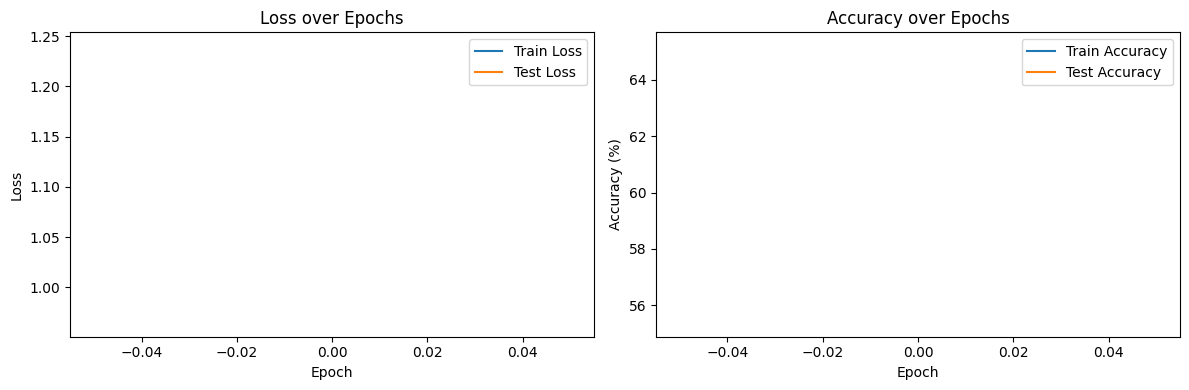


Final Test Accuracy: 65.19%
Best Test Accuracy:  65.19%


In [38]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['test_loss'], label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy')
axes[1].plot(history['test_acc'], label='Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print final results
print(f"\nFinal Test Accuracy: {history['test_acc'][-1]:.2f}%")
print(f"Best Test Accuracy:  {max(history['test_acc']):.2f}%")